# Evaluation Plots for paper

In [2]:
!rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/test.db /home/phahn/repositories/dal-toolbox/publications/cleaning_the_pool/

receiving incremental file list

sent 20 bytes  received 61 bytes  54.00 bytes/sec
total size is 3,551,232  speedup is 43,842.37


In [3]:
import os
import mlflow
import numpy as np
import pylab as plt
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from collections import defaultdict
from pathlib import Path
from cycler import cycler
import time
import datetime

# Define a custom style dictionary
custom_style = {
    # Figure and axes
    "figure.figsize": (3, 2),
    "figure.dpi": 100,
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",
    # Lines and markers
    "lines.linewidth": 1.5,
    "lines.markersize": 6,
    # Font settings
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    # Save figure settings
    "savefig.dpi": 300,
    # "axes.spines.top": False,
    # "axes.spines.right": False,
}

# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
mpl.rcParams.update(custom_style)
mpl.rcParams['axes.grid'] = True
mpl.rcParams["grid.linestyle"] = '--'
mpl.rcParams["grid.linewidth"] = .5
mpl.rcParams["grid.alpha"] = 0.7
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["#6C8EBF", "#D45D5D", "#5C985C", "#D9822B", "#65406B", "#DAB66C", "#A2D5C6", "#E699B3"])

plot_dir = Path('/home/phahn/paper_plots/adaptive_al/')
os.makedirs(plot_dir, exist_ok=True)

uri =   'sqlite://///home/phahn/repositories/dal-toolbox/publications/cleaning_the_pool/test.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
print([(exp.name, datetime.date.fromtimestamp(exp.last_update_time/1000).strftime("%d-%m-%y")) for exp in client.search_experiments()])

2026/02/19 09:16:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/19 09:16:27 INFO mlflow.store.db.utils: Updating database tables
2026-02-19 09:16:27 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2026-02-19 09:16:27 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2026-02-19 09:16:27 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2026-02-19 09:16:27 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


[('autoal_test', '12-02-26'), ('Default', '12-02-26')]


In [4]:
def get_runs(uri, exp_name, query_list="", after=None, before=None, **kwargs):
    client = mlflow.tracking.MlflowClient(tracking_uri=uri)
    experiment_id = client.get_experiment_by_name(exp_name).experiment_id
    max_res = kwargs.get('max_results', 10000)
    runs = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list), max_results=max_res)
    if after is not None:
        runs = [run for run in runs if (run.info.end_time / 1000) > after]
    if before is not None:
        runs = [run for run in runs if (run.info.end_time / 1000) < before]
    runs = sorted(runs, key=lambda run: int(run.data.params['random_seed']))
    return runs

def get_metric(run, uri, metric):
    client = mlflow.tracking.MlflowClient(uri)
    m_values = [m.value for m in client.get_metric_history(run.info.run_id, metric)]
    return m_values

def get_avg_lc(runs, uri, metric='accuracy', return_std=False):
    lcs = []
    for run in runs:
        m_values = get_metric(run, uri, metric)
        if len(m_values) == 0:
            print(f'No metric values found for run {run.info.run_id}.')
        if len(m_values) != 21:
            continue
        lcs.append(m_values)
    avg_lc = np.mean(lcs, axis=0)
    if return_std:
        std_lc = np.std(lcs, axis=0)
        return avg_lc, std_lc 
    return avg_lc
    
def get_axis_from_run(run):
    acq_size = eval(run.data.params['dataset.acq_size'])
    num_acq = eval(run.data.params['dataset.num_acq'])
    budget = acq_size + num_acq*acq_size
    axis = np.arange(acq_size, budget+1, acq_size)
    return axis

In [5]:
exp_name = 'autoal_test'

all_strategies = ['random', 'uncertainty_herding', 'autoal']

datasets = ['cifar10', 'dopanim', 'cifar100'] #TODO: Await AutoAL results
backbones = ['dinov3']

all_lcs = {}

for bb in backbones:
    if bb not in all_lcs:
        all_lcs[bb] = {}
    for dset in datasets:
        if dset not in all_lcs[bb]:
            all_lcs[bb][dset] = {}
        for strat in all_strategies:
            all_lcs[bb][dset][strat] = {}
            runs = get_runs(uri, exp_name, [f"parameter.dataset.name = '{dset}'", f"parameter.al.strategy = '{strat}'", f"parameter.model.backbone = '{bb}'"])
            runs = sorted(runs, key=lambda run: int(run.data.params['random_seed']))
            for run in runs:
                seed = run.data.params['random_seed']
                accs = get_metric(run, uri, 'accuracy')
                if len(accs) == 21: #TODO: Fixme hardcoded
                    all_lcs[bb][dset][strat][seed] = accs
                else:
                    print("Run with not enough acc values?=", bb, dset, strat, seed)

In [6]:
all_lcs_array = {}
seeds = [str(i) for i in range(1,11)]

for bb in backbones:
    all_lcs_array[bb] = {}
    for dset in datasets:
        all_lcs_array[bb][dset] = {}
        for strat in all_strategies:
            if len(all_lcs[bb][dset][strat].values()) == 0:
                print("Experiment Missing:", bb, dset, strat)
            elif len(all_lcs[bb][dset][strat].values()) != 10:
                for seed in seeds:
                    if seed not in all_lcs[bb][dset][strat]:
                        print(f'"{strat},{dset},{bb},{seed}"')
            else:
                all_lcs_array[bb][dset][strat] = np.array(list(all_lcs[bb][dset][strat].values()))

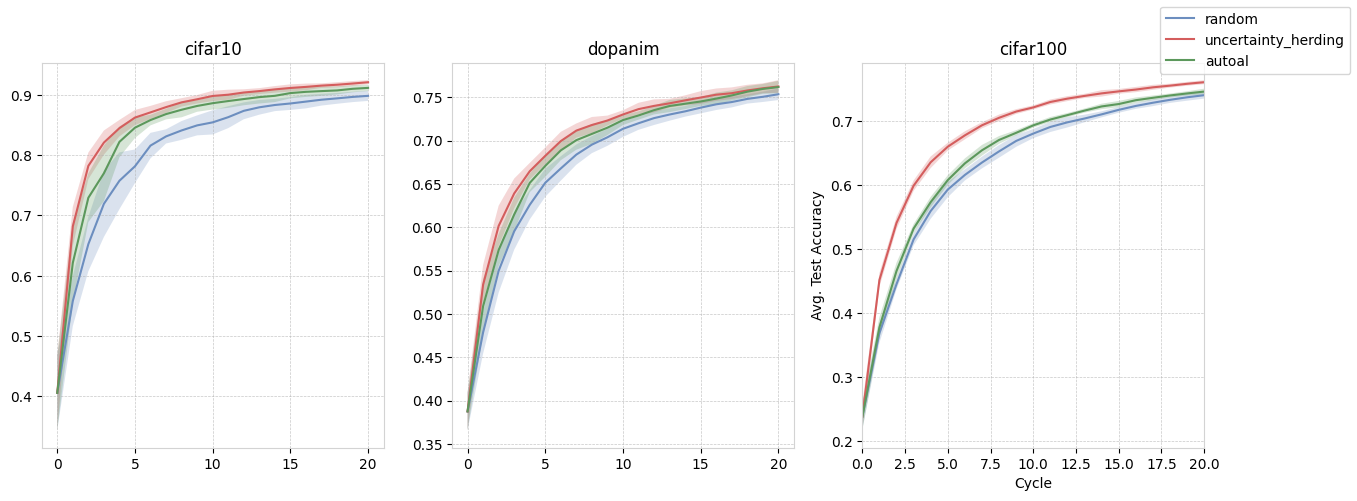

In [7]:
fig, ax = plt.subplots(ncols=3, figsize=(15, 5))

for i, dset in enumerate(all_lcs_array['dinov3']):
    plt.axes(ax[i])
    plt.title(dset)
    for strat in all_lcs_array['dinov3'][dset]:
        plt.plot(range(21), np.mean(all_lcs_array['dinov3'][dset][strat], axis=0), label=strat)
        plt.fill_between(x=range(21), y1=np.mean(all_lcs_array['dinov3'][dset][strat], axis=0) - np.std(all_lcs_array['dinov3'][dset][strat], axis=0), 
                         y2=np.mean(all_lcs_array['dinov3'][dset][strat], axis=0) + np.std(all_lcs_array['dinov3'][dset][strat], axis=0), alpha=0.25)
handles = []
labels = []

for a in ax:
    h, l = a.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Remove duplicates while preserving order
unique = dict(zip(labels, handles))
plt.xlabel("Cycle")
plt.xlim(0,20)
plt.ylabel("Avg. Test Accuracy")
fig.legend(unique.values(), unique.keys())
plt.show()